In [25]:
# initializations
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats

data_file = pd.read_excel("Data_BA_Thesis.xlsx", sheet_name="Data_BA_Thesis")
df = data_file.copy()

### Notes
- Use *Pingouin* to calculate cronbach's alpha 

# Data cleaning


In [26]:
current_n = n_pre = len(df)
shape_pre = df.shape

# Removing rows with missing values in columns that aren't demographic variables
demographic_columns = ['IDnr', 'Gender', 'Race', 'Education', 'Marital', 'Age']
df_clean = df.dropna(subset=[col for col in df.columns if col not in demographic_columns])

# Filtering columns to the one's relevant for this study
columns_to_keep = demographic_columns + [col for col in df_clean.columns if 'DIRI-RS' in col or 'FSQ' in col or 'BDI' in col]
df_clean = df_clean.loc[:, columns_to_keep]

n_post = len(df_clean)
shape_post = df_clean.shape
print(f"Remaining observations: {n_post} from {n_pre} ({n_post / n_pre * 100:.2f}%)")
print(f"Columns remaining: {df_clean.columns.tolist()}")
print(f"Shape before: {shape_pre}")
print(f"Shape after:  {shape_post}")


Remaining observations: 295 from 311 (94.86%)
Columns remaining: ['IDnr', 'Gender', 'Race', 'Education', 'Marital', 'Age', 'BDI1', 'BDI2', 'BDI3', 'BDI4', 'BDI5', 'BDI6', 'BDI7', 'BDI8', 'BDI9', 'BDI10', 'BDI11', 'BDI12', 'BDI13', 'BDI14', 'BDI15', 'BDI16', 'BDI17', 'BDI18', 'BDI19', 'BDI20', 'BDI21', 'FSQ_social_1', 'FSQ_social_2', 'FSQ_social_3', 'FSQ_social_4', 'FSQ_social_5', 'FSQ_social_6', 'FSQ_intellectual_1', 'FSQ_intellectual_2', 'FSQ_intellectual_3', 'FSQ_intellectual_4', 'FSQ_intellectual_5', 'FSQ_intellectual_6', 'FSQ_artistic/musical_1', 'FSQ_artistic/musical_2', 'FSQ_artistic/musical_3', 'FSQ_artistic/musical_4', 'FSQ_artistic/musical_5', 'FSQ_artistic/musical_6', 'FSQ_physical_1', 'FSQ_physical_2', 'FSQ_physical_3', 'FSQ_physical_4', 'FSQ_physical_5', 'FSQ_physical_6', 'FSQ_atlethic_1', 'FSQ_atlethic_2', 'FSQ_atlethic_3', 'FSQ_atlethic_4', 'FSQ_atlethic_5', 'FSQ_atlethic_6', 'DIRI-RS1', 'DIRI-RS2', 'DIRI-RS3', 'DIRI-RS4']
Shape before: (311, 383)
Shape after:  (295, 61)


# Turning encoded variables back into text

In [27]:
df_clean['Gender_E'] = df_clean['Gender'].astype('category').cat.rename_categories({            
        1: 'Male', 
        2: 'Female', 
        3: 'Non-binary',
})
df_clean['Race_E'] = df_clean['Race'].astype('category').cat.rename_categories({                
        1: 'White', 
        2: 'Hispanic, Latino/a, or Spanish origin', 
        3: 'Black or African American', 
        4: 'Asian',
        5: 'Native Hawaiian or Other Pacific Islander', 
        6: 'Native American or Alaska Native',
        7: 'Middle Eastern or North African',
        8: 'Other',
        9: 'Multiracial'
})
df_clean['Education_E'] = df_clean['Education'].astype('category').cat.rename_categories({      
        1: "Some high school",
        2: "No diploma",
        3: "High school graduate diploma or the equivalent",
        5: "Trade/technical/vocational training",
        6: "Bachelor’s degree",
        7: "Master’s degree",
        8: "Professional degree",
        9: "Doctorate degree"
})
df_clean['Marital_E'] = df_clean['Marital'].astype('category').cat.rename_categories({          
        1: 'Single or never married',
        2: 'Married or domestic partnership',
        3: 'Widowed/Widower',
        4: 'Divorced',
        5: 'Separated',
        6: 'Missing value'
})

## Generating APA table for demographics

In [ ]:
demographic_table = pd.DataFrame()
for col in ['Gender_E', 'Race_E', 'Education_E', 'Marital_E']:
    counts = df_clean[col].value_counts(sort=False)
    percentages = df_clean[col].value_counts(sort=False, normalize=True).mul(100).round(2)
    table = pd.DataFrame({'n': counts, '%': percentages})
    header = pd.DataFrame({'n': [""], '%': [""]}, index=[col.split("_")[0]])
    
    demographic_table = pd.concat([demographic_table, header, table])
    
demographic_table.reset_index(inplace=True)
demographic_table.columns = ['Characteristic', 'n', '%']

demographic_table

,Characteristic,n,%
0,Gender_E,,
1,Male,159,53.9
2,Female,136,46.1
3,Race_E,,
4,White,204,69.15
5,"Hispanic, Latino/a, or Spanish origin",11,3.73
6,Black or African American,43,14.58
7,Asian,15,5.08
8,Native American or Alaska Native,5,1.69
9,Middle Eastern or North African,1,0.34


# Calculating total and mean centered scores for each participant

In [29]:
df_analysis = df_clean[['IDnr']].copy()
df_analysis['BDI_t'] = df_clean.loc[:, [col for col in df_clean if 'BDI' in col]].sum(axis=1)
df_analysis['ERS_t'] = df_clean.loc[:, [col for col in df_clean if 'DIRI-RS' in col]].sum(axis=1)

# Grabbing all the negatively phrased items from the FSQ
negative_columns = ['FSQ_social_2', 'FSQ_social_4', 'FSQ_social_6', 
                    'FSQ_intellectual_2', 'FSQ_intellectual_3', 'FSQ_intellectual_6', 
                    'FSQ_artistic/musical_1', 'FSQ_artistic/musical_4', 'FSQ_artistic/musical_6', 
                    'FSQ_physical_2', 'FSQ_physical_3', 'FSQ_physical_6', 
                    'FSQ_atlethic_2', 'FSQ_atlethic_4', 'FSQ_atlethic_6'
                    ]
df_analysis.loc[:, 'NFS_t'] = df_clean.loc[:, negative_columns].sum(axis=1)

# Centering variables on their mean
df_analysis['BDI_c'] = df_analysis['BDI_t'] - df_analysis['BDI_t'].mean()
df_analysis['ERS_c'] = df_analysis['ERS_t'] - df_analysis['ERS_t'].mean()
df_analysis['NFS_c'] = df_analysis['NFS_t'] - df_analysis['NFS_t'].mean()

# Calculating the interaction term
df_analysis['ERSxNFS'] = df_analysis['ERS_c'] * df_analysis['NFS_c']

df_analysis.set_index('IDnr', inplace=True)
df_analysis.describe()

,BDI_t,ERS_t,NFS_t,BDI_c,ERS_c,NFS_c,ERSxNFS
count,295.000000,295.000000,295.000000,2.950000e+02,2.950000e+02,2.950000e+02,295.000000
mean,19.162712,11.037288,3.206780,-1.541516e-15,-5.058101e-16,1.204310e-17,2.341442
std,13.521234,7.472988,2.191811,1.352123e+01,7.472988e+00,2.191811e+00,15.887350
min,0.000000,4.000000,0.000000,-1.916271e+01,-7.037288e+00,-3.206780e+00,-47.805849
25%,8.000000,4.000000,1.000000,-1.116271e+01,-7.037288e+00,-2.206780e+00,-5.582120
50%,18.000000,8.000000,3.000000,-1.162712e+00,-3.037288e+00,-2.067797e-01,1.455168
75%,30.000000,18.000000,5.000000,1.083729e+01,6.962712e+00,1.793220e+00,12.716185
max,56.000000,28.000000,10.000000,3.683729e+01,1.696271e+01,6.793220e+00,88.058558


# Fitting the regression model

In [30]:
# Define the predictor and outcome variables
X = df_analysis[['ERS_c', 'NFS_c', 'ERSxNFS']]
X = sm.add_constant(X)  # Adds intercept term
y = df_analysis['BDI_t']
# Fit the model
model = sm.OLS(y, X).fit()

# View summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  BDI_t   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     32.27
Date:                Mon, 14 Apr 2025   Prob (F-statistic):           4.88e-18
Time:                        19:31:09   Log-Likelihood:                -1144.0
No. Observations:                 295   AIC:                             2296.
Df Residuals:                     291   BIC:                             2311.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.2610      0.693     27.785      0.0

In [31]:
## Bootstrapping the regression coefficients
def bootstrap_regression(data, formula, n_bootstraps=10000):
    coefs = []

    for _ in range(n_bootstraps):
        sample = data.sample(n=len(data), replace=True)
        model = smf.ols(formula=formula, data=sample).fit()
        coefs.append(model.params)

    return pd.DataFrame(coefs)

formula = "BDI_t ~ ERS_c * NFS_c"
boot_results = bootstrap_regression(df_analysis, formula)
boot_ci = boot_results.quantile([0.025, 0.975])
print(boot_ci)


       Intercept     ERS_c     NFS_c  ERS_c:NFS_c
0.025  17.836405  0.624449  0.414755    -0.114854
0.975  20.683435  1.001705  1.675082     0.044239


# Checking assumptions

### Plotting variable histograms

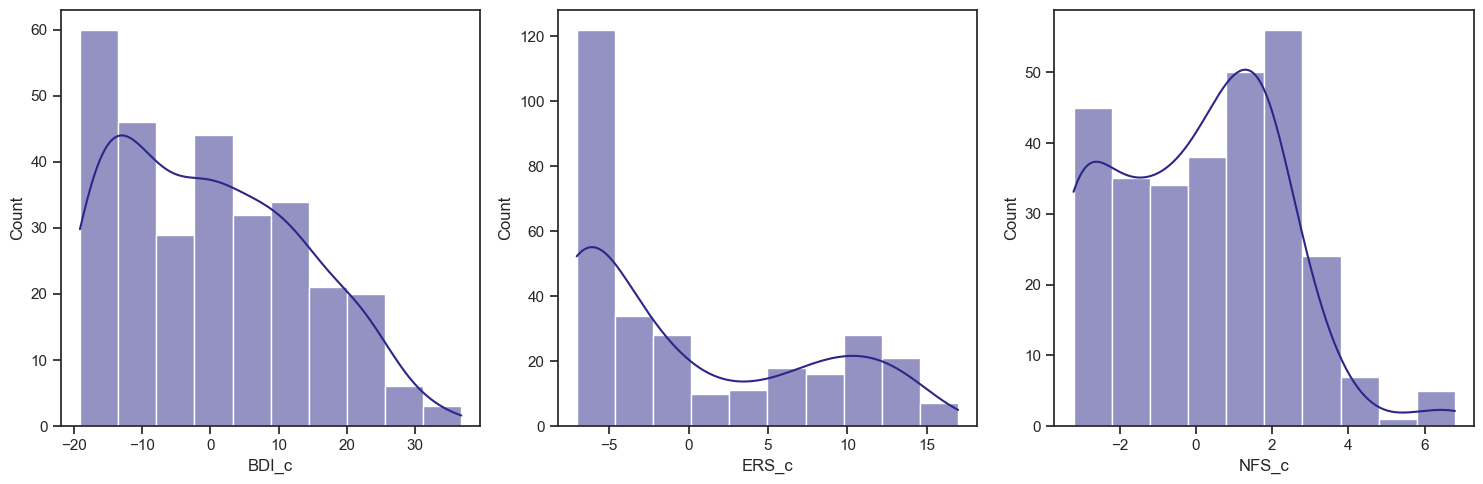

In [52]:

sns.set_theme(style='ticks', palette='CMRmap')
sns.set_context("notebook")


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df_analysis['BDI_c'], kde=True, ax=axs[0])
sns.histplot(df_analysis['ERS_c'], kde=True, ax=axs[1])
sns.histplot(df_analysis['NFS_c'], kde=True, ax=axs[2])

plt.tight_layout()
plt.show()

### Normality of residuals

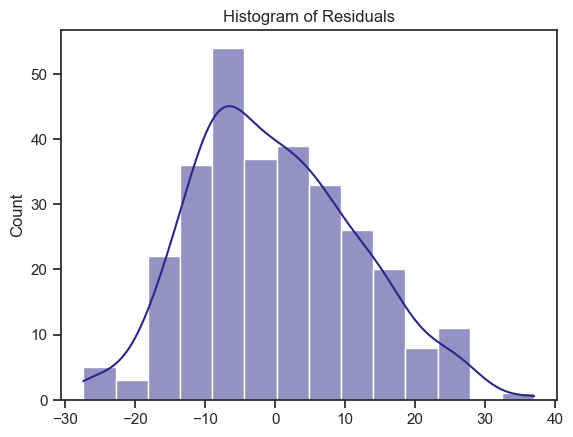

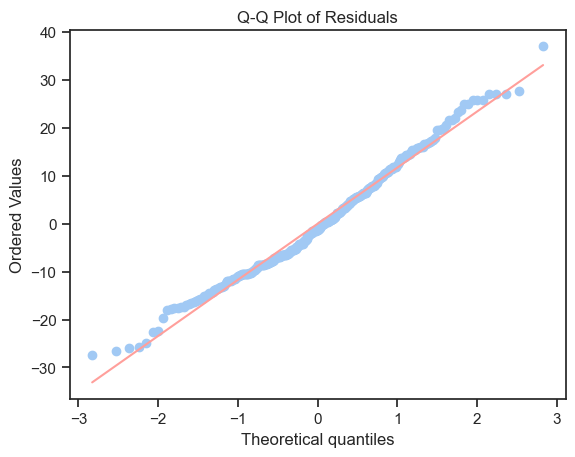

Shapiro-Wilk test statistic: 0.98633
  Shapiro-Wilk test p-value: 0.00670


In [53]:
residuals = model.resid

# Histogram with KDE
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Shapiro-Wilk test
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test statistic: {shapiro_test.statistic:.5f}")
print(f"{'Shapiro-Wilk test p-value:':>28} {shapiro_test.pvalue:.5f}")


### Linearity

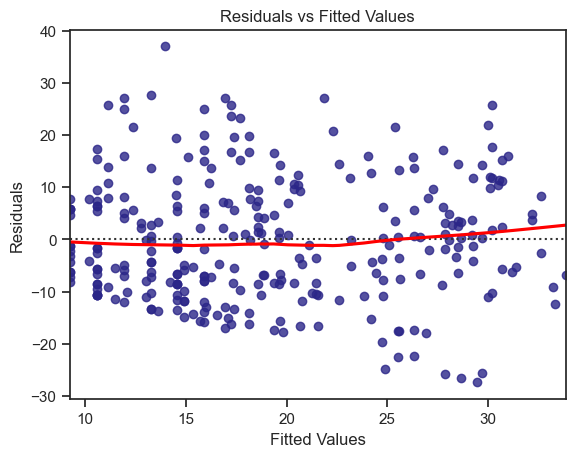

In [54]:
fitted_vals = model.fittedvalues
sns.residplot(x=fitted_vals, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

### Homoscedasticity 

In [55]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['Lagrange multiplier', 'p-value', 'f-value', 'f p-value']
result = dict(zip(labels, bp_test))

for key, value in result.items():
    print(f"{key:>20}: {value:.4f}")



 Lagrange multiplier: 4.3582
             p-value: 0.2253
             f-value: 1.4545
           f p-value: 0.2271


### Multicollinearity

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.set_index("feature", inplace=True)

print(vif_data)

              VIF
feature          
const    1.022877
ERS_c    1.058240
NFS_c    1.041382
ERSxNFS  1.049708
